# Paper 4 — 02 · Detection vs execution probes (H1a / H1b)

Per-layer detection (harm vs benign) and execution (refuse vs comply) probes. Train on EN activations, evaluate in-language (EN ceiling) and zero-shot on RO (transfer). The per-layer EN->RO accuracy drop is the H1a/H1b signal. **Bands are read off the EN in-language curve only**, before any RO number (EXPERIMENT_DESIGN §4.3) — pre-registered.

**Output:** `data/probes/<short>/`, `results/<short>/linear_probes.json`, `results/<short>/bands.json`.

In [1]:
%%capture
# Pinned to requirements.txt. Wheel-only on A100 / CUDA 12; restart rarely needed.
!pip install -U \
    'transformers>=4.51' \
    'accelerate>=1.1' \
    'datasets>=3.0' \
    'scikit-learn>=1.4' \
    'transformer-lens>=2.9' \
    'sae-lens>=4.0' \
    python-dotenv requests huggingface_hub ipywidgets pyyaml matplotlib seaborn -q


In [2]:
import os, json, gc, sys, hashlib, subprocess
from pathlib import Path
from datetime import datetime
import torch

# --- Drive ---
from google.colab import drive
drive.mount("/content/drive")

# --- Secrets (Colab) -> env, so the Paper 2 judge + gated HF models work
#     end-to-end with no manual steps. Set these in Colab -> Secrets first. ---
try:
    from google.colab import userdata
    for _k in ("OPENROUTER_API_KEY", "HF_TOKEN"):
        try:
            _v = userdata.get(_k)
            if _v:
                os.environ[_k] = _v
        except Exception:
            print(f"[secrets] {_k} not set in Colab Secrets — add it if a cell needs it.")
except Exception:
    pass
if os.environ.get("HF_TOKEN"):
    from huggingface_hub import login
    login(os.environ["HF_TOKEN"], add_to_git_credential=False)

# --- Artifact root (persistent, on Drive) ---
DRIVE_ROOT  = Path("/content/drive/MyDrive/PhD/paper4-interpretability")
PAPER2_ROOT = Path("/content/drive/MyDrive/PhD/paper2-benchmark")
PAPER3_ROOT = Path("/content/drive/MyDrive/PhD/paper3-alignment")

# --- Code root: use the repo synced on Drive if present, else clone the public
#     repo to /content. Self-provisioning AND self-updating: if the /content
#     clone already exists we `git pull` it, so you always get the latest code. ---
REPO_URL = "https://github.com/robery567/rosafety-circuits.git"
if (DRIVE_ROOT / "src" / "paths.py").exists():
    CODE_ROOT = DRIVE_ROOT
else:
    CODE_ROOT = Path("/content/rosafety-circuits")
    if (CODE_ROOT / ".git").exists():
        print("Updating Paper 4 code (git pull):", CODE_ROOT)
        subprocess.run(["git", "-C", str(CODE_ROOT), "pull", "-q", "--ff-only"], check=False)
    else:
        print("Cloning Paper 4 code:", REPO_URL)
        subprocess.run(["git", "clone", "-q", REPO_URL, str(CODE_ROOT)], check=True)
print("CODE_ROOT :", CODE_ROOT)
print("DRIVE_ROOT:", DRIVE_ROOT)

# --- data dirs (Drive, persistent across sessions) ---
DATA_DIR     = DRIVE_ROOT / "data"
CONTRAST_DIR = DATA_DIR / "contrastive"
ACT_DIR      = DATA_DIR / "activations"
PROBE_DIR    = DATA_DIR / "probes"
SPLITS_DIR   = DATA_DIR / "splits"
RESULTS_DIR  = DRIVE_ROOT / "results"
FIG_DIR      = DRIVE_ROOT / "figures"
LOGS_DIR     = DRIVE_ROOT / "logs"
for d in [CONTRAST_DIR, ACT_DIR, PROBE_DIR, SPLITS_DIR, RESULTS_DIR, FIG_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
CONFIG_DIR = CODE_ROOT / "configs"   # configs live in the repo, not in data/

# --- Reuse Paper 2 judge harness; Paper 4 src/ from CODE_ROOT ---
sys.path.insert(0, str(PAPER2_ROOT / "src"))      # judges.py, llm_judge.py
sys.path.insert(0, str(CODE_ROOT / "src"))         # paths, capture, probes, patching, sae_utils, contrastive, behavioral

# Drop any cached Paper 4 modules so a fresh import picks up a just-pulled
# version without needing a kernel restart.
for _m in ("paths", "capture", "probes", "patching", "sae_utils", "contrastive", "behavioral"):
    sys.modules.pop(_m, None)

# --- A100 sanity ---
assert torch.cuda.is_available(), "Need a GPU runtime (A100 high-RAM)."
torch.backends.cuda.matmul.allow_tf32 = True
print("GPU:", torch.cuda.get_device_name(0))
print("torch:", torch.__version__)


Mounted at /content/drive


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cloning Paper 4 code: https://github.com/robery567/rosafety-circuits.git
CODE_ROOT : /content/rosafety-circuits
DRIVE_ROOT: /content/drive/MyDrive/PhD/paper4-interpretability
GPU: NVIDIA A100-SXM4-80GB
torch: 2.7.1+cu126


## Configuration

In [3]:
# --- Anchor selection. Re-run the notebook once per anchor. ---
# All three are the exact Paper 3 anchors (probes + patching + H1d):
#   google/gemma-3-4b-it  (also the SAE anchor for H1e, via Gemma Scope 2)
#   Qwen/Qwen2.5-3B-Instruct
#   meta-llama/Llama-3.2-3B-Instruct
ANCHOR = "google/gemma-3-4b-it"

from paths import short_of, family_of
short  = short_of(ANCHOR)
family = family_of(ANCHOR)
print(f"ANCHOR : {ANCHOR}\nfamily : {family}\nshort  : {short}")


ANCHOR : google/gemma-3-4b-it
family : gemma3
short  : gemma-3-4b


## 1. Load contrastive cells + behavioral labels + probe split (from nb01)

In [4]:
out = CONTRAST_DIR / short
def _read(name):
    p = out / f'{name}.jsonl'
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()]
cells = {n: _read(n) for n in ['harm_en','benign_en','harm_ro','benign_ro']}
beh = {json.loads(l)['id']: json.loads(l)['label']
       for l in (out / 'behavioral_labels.jsonl').read_text().splitlines() if l.strip()}
split = json.loads((SPLITS_DIR / f'probe_split_{short}.json').read_text())
train_ids = set(split['train_en'])
print({n: len(v) for n, v in cells.items()}, 'beh labels:', len(beh))

{'harm_en': 236, 'benign_en': 250, 'harm_ro': 100, 'benign_ro': 100} beh labels: 808


## 2. Load anchor + capture residuals (cached to Drive)

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from capture import capture_assistant_prefix
tok = AutoTokenizer.from_pretrained(ANCHOR); tok.padding_side='left'
if tok.pad_token is None: tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(ANCHOR, torch_dtype=torch.bfloat16, device_map='cuda').eval()
from capture import n_layers
n_blocks = n_layers(model)
def capture_cell(name):
    cache = ACT_DIR / short / f'{name}.pt'; cache.parent.mkdir(parents=True, exist_ok=True)
    if cache.exists():
        a = torch.load(cache)
        if a.shape[0] == len(cells[name]): return a
        print(f'  stale cache for {name} ({a.shape[0]} != {len(cells[name])} rows); recomputing')
    acts = capture_assistant_prefix(model, tok, [r['text'] for r in cells[name]])
    torch.save(acts, cache); return acts
acts = {n: capture_cell(n) for n in cells}
print('captured', {n: tuple(a.shape) for n, a in acts.items()})

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

captured {'harm_en': (236, 34, 2560), 'benign_en': (250, 34, 2560), 'harm_ro': (100, 34, 2560), 'benign_ro': (100, 34, 2560)}


## 3. Assemble EN/RO matrices (detection = intent; execution = behavior)

In [6]:
import numpy as np
def stack(names):
    A = np.concatenate([acts[n].float().numpy() for n in names], 0)
    rows = [r for n in names for r in cells[n]]
    ids = [r['id'] for r in rows]
    y_int = np.array([1 if r['label']=='harmful' else 0 for r in rows])
    y_beh = np.array([1 if beh.get(i)=='refuse' else 0 for i in ids])
    return A, ids, y_int, y_beh
A_en, ids_en, yint_en, ybeh_en = stack(['harm_en','benign_en'])
A_ro, ids_ro, yint_ro, ybeh_ro = stack(['harm_ro','benign_ro'])
train_mask = np.array([i in train_ids for i in ids_en])
print('EN', A_en.shape, 'train', int(train_mask.sum()), '| RO', A_ro.shape)

EN (486, 34, 2560) train 340 | RO (200, 34, 2560)


## 4. Fit per-layer detection (H1a) + execution (H1b) probes

In [7]:
from probes import fit_all_layers, compose_bands
det = fit_all_layers(A_en, yint_en, train_mask, A_ro, yint_ro)   # harm vs benign
exe = fit_all_layers(A_en, ybeh_en, train_mask, A_ro, ybeh_ro)   # refuse vs comply
bands = compose_bands([r.acc_en_held for r in det.per_layer],
                      [r.acc_en_held for r in exe.per_layer], n_blocks)
print('bands:', {k: bands[k] for k in ['detection','execution','overlap_warning']})

bands: {'detection': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'execution': [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], 'overlap_warning': False}


## 5. Save results + bands (pre-registered: bands read off EN curves only)

In [8]:
rs = RESULTS_DIR / short; rs.mkdir(parents=True, exist_ok=True)
(rs / 'bands.json').write_text(json.dumps(bands, indent=2))
per_layer = [{'layer': l,
  'det_acc_en': det.per_layer[l].acc_en_held, 'det_acc_ro': det.per_layer[l].acc_ro, 'det_drop': det.per_layer[l].drop,
  'det_acc_en_wilson95': list(det.per_layer[l].acc_en_held_wilson), 'det_acc_ro_wilson95': list(det.per_layer[l].acc_ro_wilson),
  'exe_acc_en': exe.per_layer[l].acc_en_held, 'exe_acc_ro': exe.per_layer[l].acc_ro, 'exe_drop': exe.per_layer[l].drop}
  for l in range(n_blocks)]
(rs / 'linear_probes.json').write_text(json.dumps({'anchor_model': ANCHOR, 'short': short,
  'n_blocks': n_blocks, 'bands': bands, 'per_layer': per_layer}, indent=2))
print('wrote', rs / 'linear_probes.json')

wrote /content/drive/MyDrive/PhD/paper4-interpretability/results/gemma-3-4b/linear_probes.json


## 6. Plot transfer-drop curves (H1a large in detection band; H1b small in execution band)

[save_camera_ready] fell back to png: /content/drive/MyDrive/PhD/paper4-interpretability/figures/transfer_drop_gemma-3-4b.png


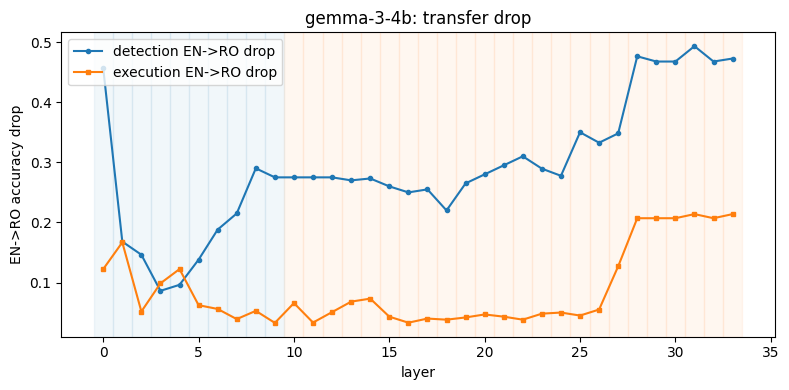

In [9]:
import matplotlib.pyplot as plt
from pathlib import Path
def save_camera_ready(fig, path_no_ext, dpi=600):
    path_no_ext = Path(path_no_ext).with_suffix('')
    for ext, backend in [('pdf', None), ('pdf', 'cairo'), ('svg', None), ('png', None)]:
        out = path_no_ext.with_suffix(f'.{ext}')
        try:
            kw = {'bbox_inches': 'tight'}
            if backend: kw['backend'] = backend
            if ext == 'png': kw['dpi'] = dpi
            fig.savefig(out, **kw)
            if backend or ext != 'pdf':
                print(f'[save_camera_ready] fell back to {ext}' + (f' ({backend})' if backend else '') + f': {out}')
            return out
        except Exception as e:
            last_err = e
    raise RuntimeError(f'All save methods failed; last error: {last_err}')
L = range(n_blocks)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(L, [p['det_drop'] for p in per_layer], label='detection EN->RO drop', marker='o', ms=3)
ax.plot(L, [p['exe_drop'] for p in per_layer], label='execution EN->RO drop', marker='s', ms=3)
for b in bands['detection']: ax.axvspan(b-0.5, b+0.5, color='C0', alpha=0.06)
for b in bands['execution']: ax.axvspan(b-0.5, b+0.5, color='C1', alpha=0.06)
ax.set_xlabel('layer'); ax.set_ylabel('EN->RO accuracy drop'); ax.legend(); ax.set_title(f'{short}: transfer drop')
fig.tight_layout(); save_camera_ready(fig, FIG_DIR / f'transfer_drop_{short}'); plt.show()